# Measure Receptive Field

In [2]:
import sys, os 
# sys.path.append(os.path.abspath('.'))

import torch
import torch.nn as nn
import torchaudio
import numpy as np
import gin
import rave
import types
import act_max_util as amu # no PCA
# import act_max_pca as amu # with PCA
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F
# from rave.core import get_rave_receptive_field

# Directory containing model checkpoint and config
model_dir = './checkpoints/noise_warmup_200k_latent_8'

# Load the model
config_path = rave.core.search_for_config(model_dir)
gin.parse_config_file(config_path)
model = rave.RAVE()
run = rave.core.search_for_run(model_dir)
model = model.load_from_checkpoint(run)


print(f'Model loaded from {model_dir}')
print(f'model.latent_size: {model.latent_size}')

model

/Users/DiarmuidFogarty/miniconda3/envs/RAVE/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model loaded from ./checkpoints/noise_warmup_200k_latent_8
model.latent_size: 8


RAVE(
  (pqmf): CachedPQMF(
    (forward_conv): Conv1d(1, 16, kernel_size=(513,), stride=(16,), bias=False)
    (inverse_conv): Conv1d(16, 16, kernel_size=(33,), stride=(1,), bias=False)
  )
  (spectrogram): MelSpectrogram(
    (spectrogram): Spectrogram()
    (mel_scale): MelScale()
  )
  (encoder): VariationalEncoder(
    (encoder): EncoderV2(
      (net): CachedSequential(
        (0): Conv1d(128, 96, kernel_size=(7,), stride=(1,), bias=False)
        (1): Residual(
          (aligned): Branches(
            (branches): ModuleList(
              (0): DilatedUnit(
                (net): CachedSequential(
                  (0): LeakyReLU(negative_slope=0.2)
                  (1): Conv1d(96, 96, kernel_size=(3,), stride=(1,), bias=False)
                  (2): LeakyReLU(negative_slope=0.2)
                  (3): Conv1d(96, 96, kernel_size=(1,), stride=(1,), bias=False)
                )
              )
              (1): Identity()
            )
          )
        )
        (2): Leaky

### RAVE receptive field function

This computes the receptive field of the entire model - encoder and decoder included.

In [5]:
@torch.enable_grad()
def get_rave_receptive_field(model, n_channels=1):
    N = 2**15
    model.eval()
    device = next(iter(model.parameters())).device

    for module in model.modules():
        if hasattr(module, 'gru_state') or hasattr(module, 'temporal'):
            module.disable()

    while True:
        x = torch.randn(1, model.n_channels, N, requires_grad=True, device=device)

        z = model.encode(x)
        z = model.encoder.reparametrize(z)[0]
        y = model.decode(z)

        y[0, 0, N // 2].backward()
        assert x.grad is not None, "input has no grad"

        grad = x.grad.data.reshape(-1)
        left_grad, right_grad = grad.chunk(2, 0)
        large_enough = (left_grad[0] == 0) and right_grad[-1] == 0
        if large_enough:
            break
        else:
            N *= 2
    left_receptive_field = len(left_grad[left_grad != 0])
    right_receptive_field = len(right_grad[right_grad != 0])
    model.zero_grad()

    for module in model.modules():
        if hasattr(module, 'gru_state') or hasattr(module, 'temporal'):
            module.enable()
    ratio = x.shape[-1] // z.shape[-1]
    rate = model.sr / ratio
    print(f"Compression ratio: {ratio}x (~{rate:.1f}Hz @ {model.sr}Hz)")
    return left_receptive_field, right_receptive_field

get_rave_receptive_field(model)

AssertionError: input has no grad

In [4]:
def measure_receptive_field(encoder, input_channels=128):
    """
    Measure receptive field by backpropagating from a single output timestep.
    
    Args:
        encoder: Your VariationalEncoder model
        input_channels: Number of mel bands (128 in your case)
    
    Returns:
        receptive_field: Number of input frames that influence one output
    """
    encoder.eval()
    encoder
    
    # Create a long dummy input to ensure we capture the full receptive field
    # Use a generous length (e.g., 1000 frames)
    dummy_length = 1000
    dummy_input = torch.randn(1, input_channels, dummy_length, 
                               requires_grad=True)
    
    # Forward pass
    with torch.enable_grad():
        output = encoder(dummy_input)  # Shape: (1, latent_dim, T_out)
        
        # Select a middle output timestep (to avoid boundary effects)
        middle_timestep = output.shape[2] // 2
        
        # Extract scalar value from that timestep (sum over channels for simplicity)
        target = output[0, :, middle_timestep].sum()
        
        # Backpropagate
        target.backward()
    
    # Get gradients on input
    input_grad = dummy_input.grad[0]  # Shape: (input_channels, dummy_length)
    print(dummy_input.grad.data)
    # Find where gradients are non-zero (with small tolerance for numerical precision)
    grad_magnitude = input_grad.abs().sum(dim=0)  # Sum over channels
    threshold = grad_magnitude.max() * 1e-6  # Adaptive threshold
    
    nonzero_positions = (grad_magnitude > threshold).nonzero(as_tuple=True)[0]
    
    if len(nonzero_positions) == 0:
        print("Warning: No non-zero gradients found!")
        return 0
    
    # Receptive field is the span of non-zero gradient positions
    receptive_field = nonzero_positions.max().item() - nonzero_positions.min().item() + 1
    
    # Also report the center position for verification
    center_position = (nonzero_positions.max() + nonzero_positions.min()) // 2
    output_position = middle_timestep * 8  # Adjust by compression ratio
    
    print(f"Receptive field: {receptive_field} frames")
    print(f"Non-zero gradient range: [{nonzero_positions.min().item()}, {nonzero_positions.max().item()}]")
    print(f"Output timestep {middle_timestep} corresponds to input position ~{output_position}")
    print(f"Gradient center: {center_position.item()}")
    
    return receptive_field


encoder = model.encoder.encoder

rf = measure_receptive_field(encoder, input_channels=128)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Receptive field: 58 frames
Non-zero gradient range: [471, 528]
Output timestep 62 corresponds to input position ~496
Gradient center: 499


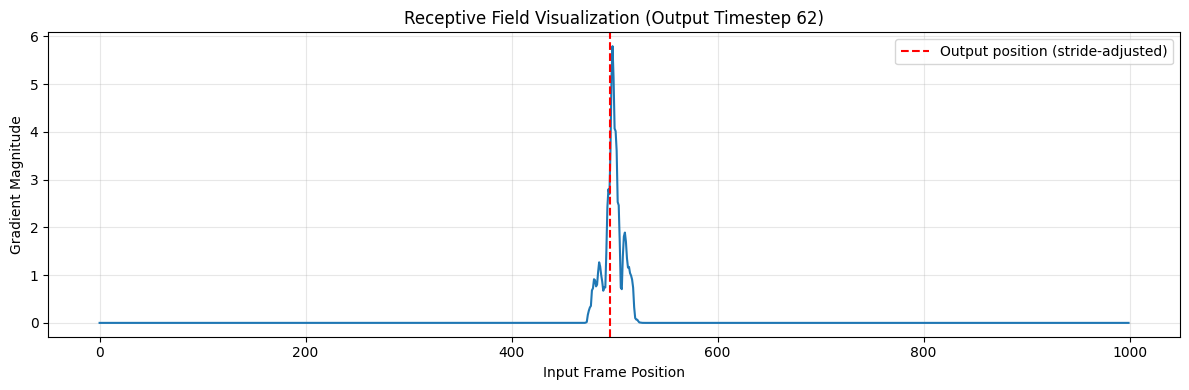

Effective receptive field (99% gradient): 25 frames


In [5]:
def visualize_receptive_field(encoder, input_channels=128):
    """
    Visualize the gradient distribution across input frames.
    """
    import matplotlib.pyplot as plt
    
    encoder.eval()
    
    dummy_length = 1000
    dummy_input = torch.randn(1, input_channels, dummy_length, 
                               requires_grad=True)
    
    with torch.enable_grad():
        output = encoder(dummy_input)
        middle_timestep = output.shape[2] // 2
        target = output[0, :, middle_timestep].sum()
        target.backward()
    
    # Get gradient magnitude
    grad_magnitude = dummy_input.grad[0].abs().sum(dim=0).cpu().numpy()
    
    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(grad_magnitude)
    plt.xlabel('Input Frame Position')
    plt.ylabel('Gradient Magnitude')
    plt.title(f'Receptive Field Visualization (Output Timestep {middle_timestep})')
    plt.axvline(middle_timestep * 8, color='r', linestyle='--', 
                label=f'Output position (stride-adjusted)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('receptive_field.png', dpi=150)
    plt.show()
    
    # Find effective receptive field (99% of gradient mass)
    cumsum = np.cumsum(np.sort(grad_magnitude)[::-1])
    threshold_99 = cumsum[-1] * 0.8
    effective_rf = np.sum(cumsum < threshold_99) + 1
    
    print(f"Effective receptive field (99% gradient): {effective_rf} frames")

# Usage
visualize_receptive_field(encoder, input_channels=128)